# Packages & Global Info

In [1]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Aggregation levels
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

# ARI

In [3]:
# ARI results
ARI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/ARI/ARI.csv", index_col=0)

ARI = {}
for col in ARI_df.columns:
    ARI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in ARI_df[col].items()
    }

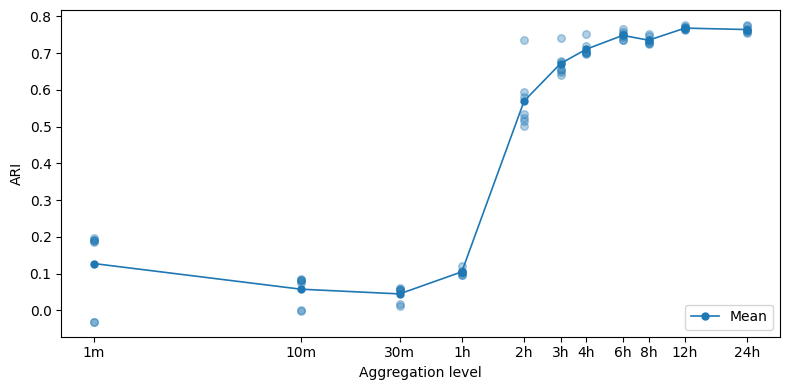

In [6]:
# Plot of ARIs & mean for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for _, h in levels.items() ])
adj_rand = [np.array(list(ARI[name].values())) for name in levels]

ari_means = np.array([ari.mean() for ari in adj_rand])

for x, aris in zip(agg_levels, adj_rand):
    ax.scatter(x * np.ones(len(aris)), aris, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, ari_means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('ARI')
ax.legend(loc='lower right')
plt.tight_layout()

# VI

In [7]:
# VI results 
VI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/VI/VI.csv", index_col=0)

VI = {}
for col in VI_df.columns:
    VI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in VI_df[col].items()
    }

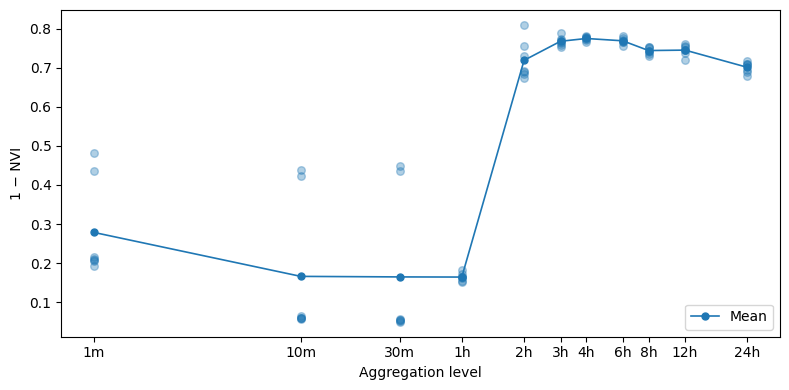

In [10]:
# Plot of (1 - NVI)s & mean for each aggregtion level
inv_VI = {name: {pair: 1 - v for pair, v in d.items()} for name, d in VI.items()}

fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for _, h in levels.items()])
sim = [np.array(list(inv_VI[name].values())) for name in levels]
inv_vi_means = np.array([s.mean() for s in sim])

for x, s in zip(agg_levels, sim):
    ax.scatter(x * np.ones(len(s)), s, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, inv_vi_means, marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('1 − NVI')
ax.legend(loc='lower right')
plt.tight_layout()

# PSI

In [11]:
# ARI results
PSI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/PSI/PSI.csv", index_col=0)

PSI = {}
for col in PSI_df.columns:
    PSI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in PSI_df[col].items()
    }

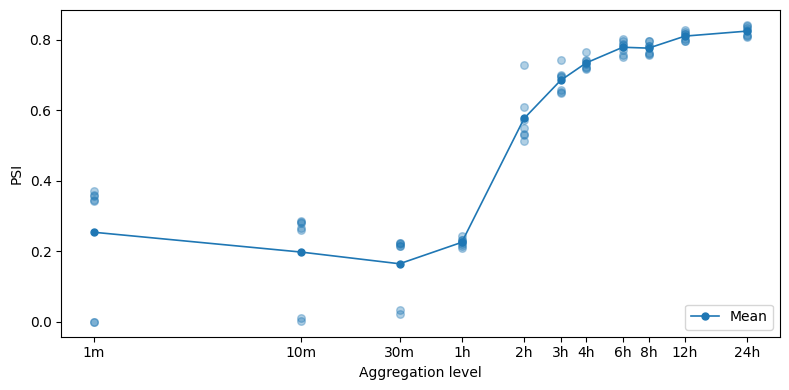

In [14]:
# Plot of PSIs & mean for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for _, h in levels.items() ])
psi_vals = [np.array(list(PSI[name].values())) for name in levels]

psi_means = np.array([psi.mean() for psi in psi_vals])

for x, aris in zip(agg_levels, psi_vals):
    ax.scatter(x * np.ones(len(aris)), aris, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, psi_means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('PSI')
ax.legend(loc='lower right')
plt.tight_layout()

# Combined

In [17]:
# Distribution of stability values for each measure 
ari_dist = np.concatenate([np.array(list(ARI[name].values())) for name in levels])
vi_dist  = np.concatenate([np.array(list(inv_VI[name].values())) for name in levels])
psi_dist = np.concatenate([np.array(list(PSI[name].values())) for name in levels])

# Mean and standard deviation of measures
ari_mean, ari_std = ari_dist.mean(), ari_dist.std()
vi_mean,  vi_std  = vi_dist.mean(),  vi_dist.std()
psi_mean, psi_std = psi_dist.mean(), psi_dist.std()

In [18]:
# Combined measure
combined_measure = {} 

for agg_level in levels:
    pairs = list(ARI[agg_level].keys())  
    z_ari = (np.array([ARI[agg_level][p] for p in pairs]) - ari_mean) / ari_std
    z_vi  = (np.array([inv_VI[agg_level][p] for p in pairs]) - vi_mean) / vi_std
    z_psi = (np.array([PSI[agg_level][p] for p in pairs]) - psi_mean) / psi_std

    combined_measure[agg_level] = (z_ari + z_vi + z_psi) / 3

In [21]:
# Scaled combined measure and compute means
all_combined = np.concatenate([combined_measure[agg_level] for agg_level in levels])
c_min, c_max = all_combined.min(), all_combined.max()

combined_scaled = {
    agg_level: (combined_measure[agg_level] - c_min) / (c_max - c_min)
    for agg_level in levels
}

combined_means = np.array([combined_scaled[agg_level].mean() for agg_level in levels])

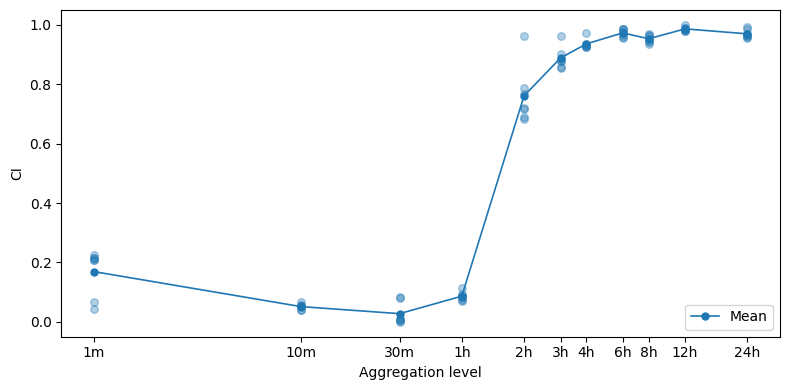

In [25]:
# Plot of combined measure & mean for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

for x, name in zip(agg_levels, levels):
    vals = combined_scaled[name]
    ax.scatter(x * np.ones(len(vals)), vals, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, combined_means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('CI')
ax.legend(loc='lower right')
plt.tight_layout()